Loading data ...
done.

[1] BASIC INTEGRITY CHECKS

-- Time continuity --
  labels: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | rows(unique dt)=26304 | missing hours=0 | dup=0
  ldaps_train: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | rows(unique dt)=26304 | missing hours=0 | dup=394560
  gfs_train: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | rows(unique dt)=26304 | missing hours=0 | dup=210432
  ldaps_test: 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00 | rows(unique dt)=8760 | missing hours=0 | dup=131400
  gfs_test: 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00 | rows(unique dt)=8760 | missing hours=0 | dup=70080

-- Grid count per timestamp (should be constant: LDAPS=16, GFS=9) --
  ldaps_train: min=16, max=16 (expect 16)
  gfs_train: min=9, max=9 (expect 9)

-- Missing values (labels) --
kst_dtm           0
kpx_group_1     104
kpx_group_2     103
kpx_group_3    8766
  * group_3 은 2022년 구간이 결측으로 제공됨 (명세서와 일치 여부 확인)
    group_3 NaN range: 2022-01-01 01:00:00 ~ 2024-07-30 14:00:00

-- Missing

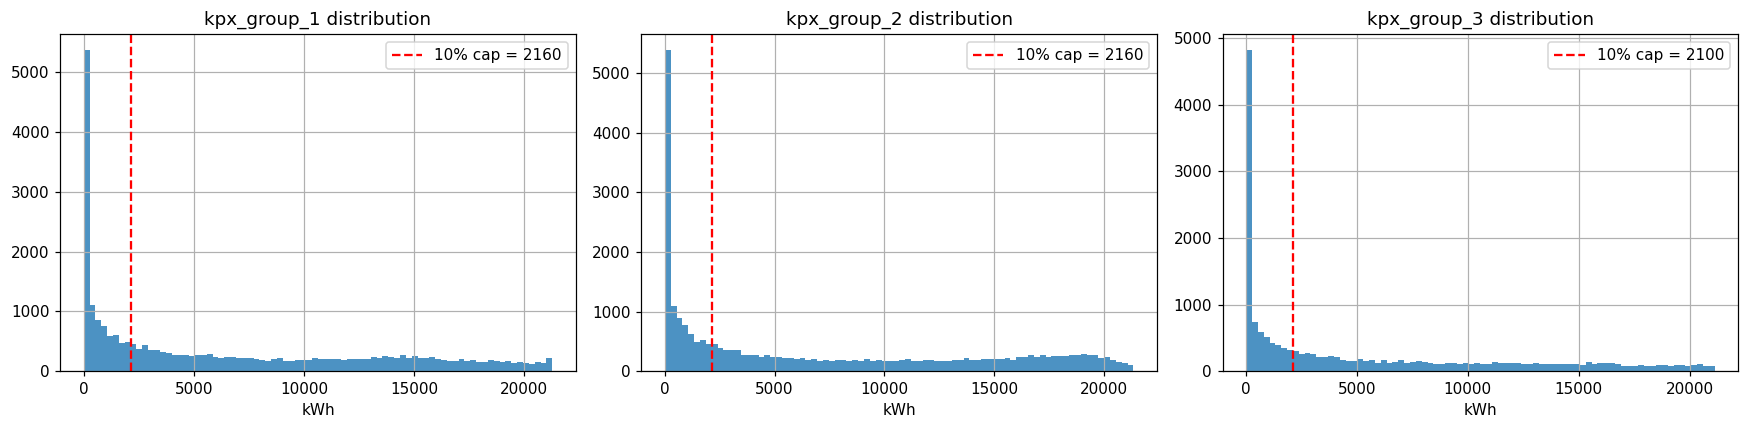


-- 10% exclusion rule impact (train period) --
  kpx_group_1:  39.3% of hours EXCLUDED from scoring (actual < 2160 kWh) -> only 60.7% evaluated
  kpx_group_2:  39.3% of hours EXCLUDED from scoring (actual < 2160 kWh) -> only 60.7% evaluated
  kpx_group_3:  46.3% of hours EXCLUDED from scoring (actual < 2100 kWh) -> only 53.7% evaluated


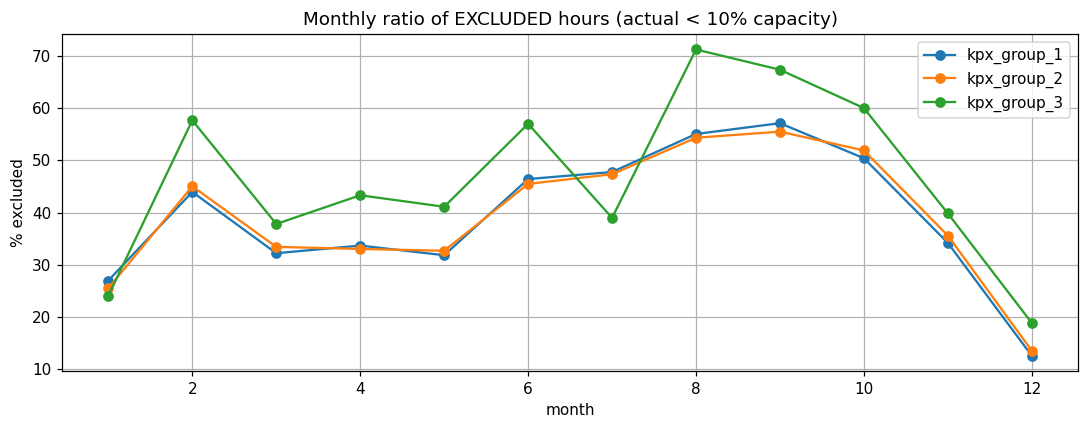

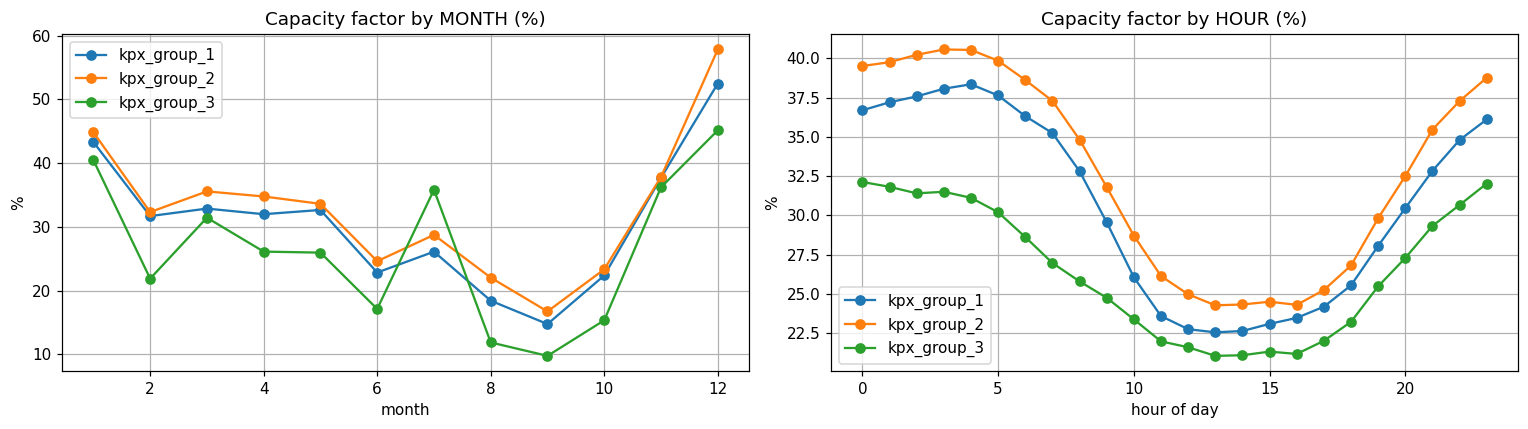


-- Yearly mean capacity factor (%) --
      kpx_group_1  kpx_group_2  kpx_group_3
year                                       
2022         30.4         34.8          NaN
2023         32.4         33.5         26.9
2024         29.2         30.0         26.1
2025         96.6         98.6         77.8

-- Inter-group correlation --
             kpx_group_1  kpx_group_2  kpx_group_3
kpx_group_1        1.000        0.955        0.904
kpx_group_2        0.955        1.000        0.928
kpx_group_3        0.904        0.928        1.000

[3] SCADA EDA

-- Glitch removal summary --
  VESTAS: values outside [-600, 780] kWh/10m -> NaN
  UNISON: values outside [-700, 910] kWh/10m -> NaN


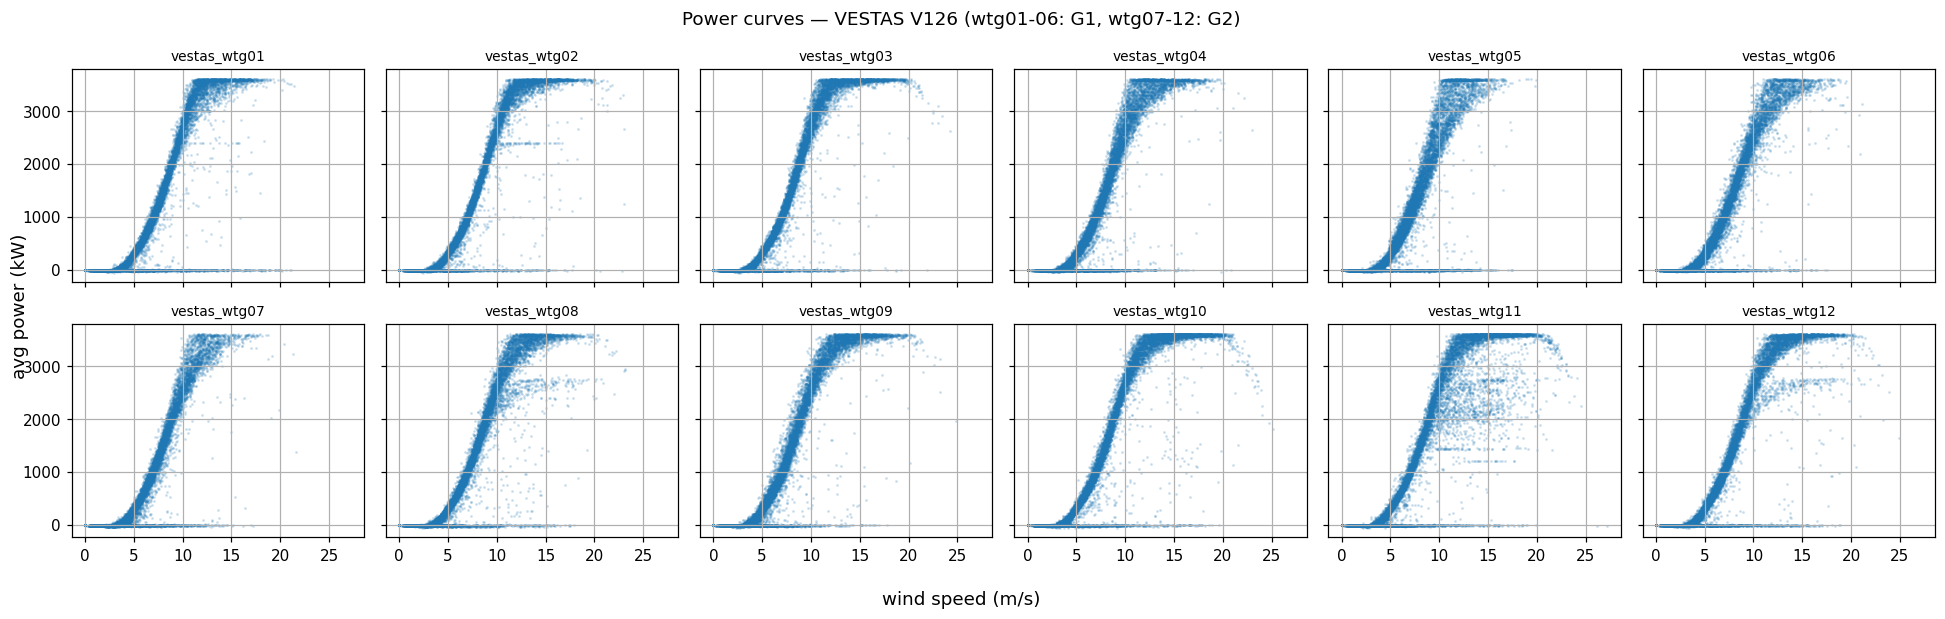

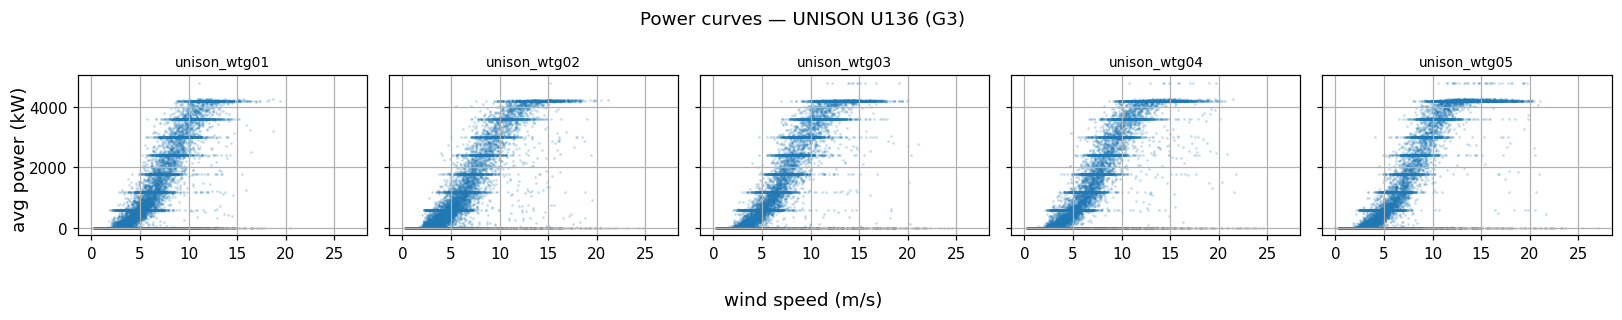


-- Anomaly: zero power despite wind >= 5 m/s (downtime proxy, % of rows) --
  vestas_wtg01:  4.82%
  vestas_wtg02:  2.61%
  vestas_wtg03:  2.69%
  vestas_wtg04:  5.15%
  vestas_wtg05:  5.03%
  vestas_wtg06:  3.81%
  vestas_wtg07:  3.65%
  vestas_wtg08:  3.17%
  vestas_wtg09:  3.42%
  vestas_wtg10:  3.48%
  vestas_wtg11:  4.19%
  vestas_wtg12:  3.77%
  unison_wtg01:  6.48%
  unison_wtg02:  3.51%
  unison_wtg03:  3.51%
  unison_wtg04:  4.52%
  unison_wtg05:  4.36%

-- SCADA hourly aggregate vs labels (correlation & MAE) --
  kpx_group_1: corr=0.9998, MAE=131 kWh, n=26,199
  kpx_group_2: corr=0.9998, MAE=124 kWh, n=26,200
  kpx_group_3: corr=0.9966, MAE=295 kWh, n=17,538
  * corr≈1 이면 라벨 = SCADA 합산과 동일 구조 → SCADA로 라벨 품질/정지 보정 판단 가능

[4] NWP (LDAPS / GFS) EDA

-- Grid-wise correlation: LDAPS ws50 vs group power --
    kpx_group_1  kpx_group_2  kpx_group_3
1         0.691        0.704        0.701
2         0.757        0.767        0.758
3         0.768        0.777        0.766
4        

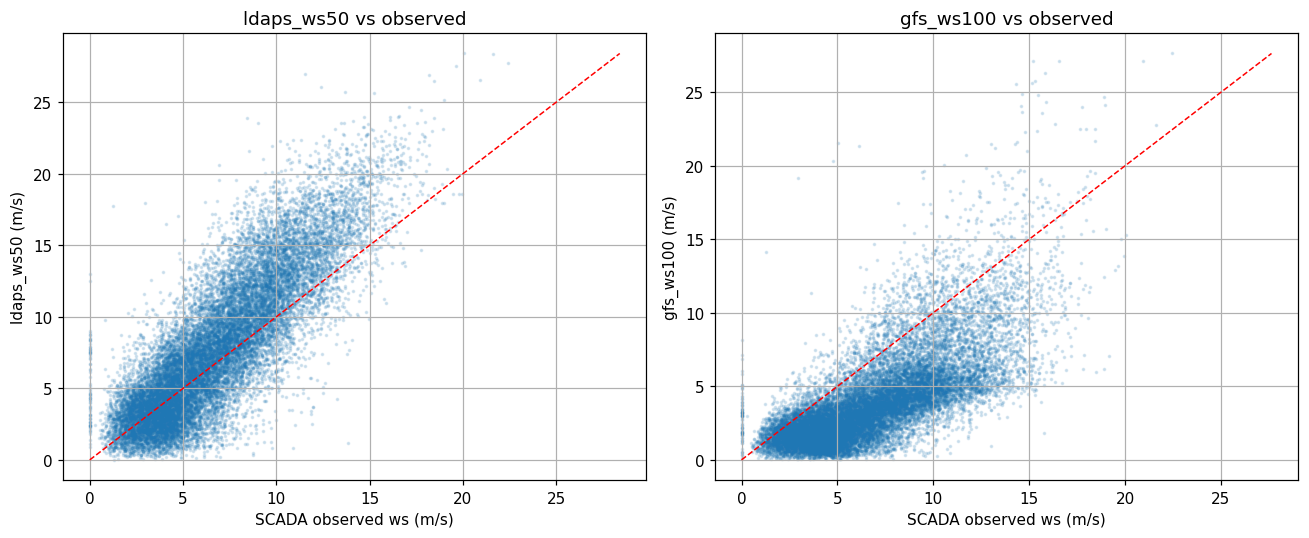

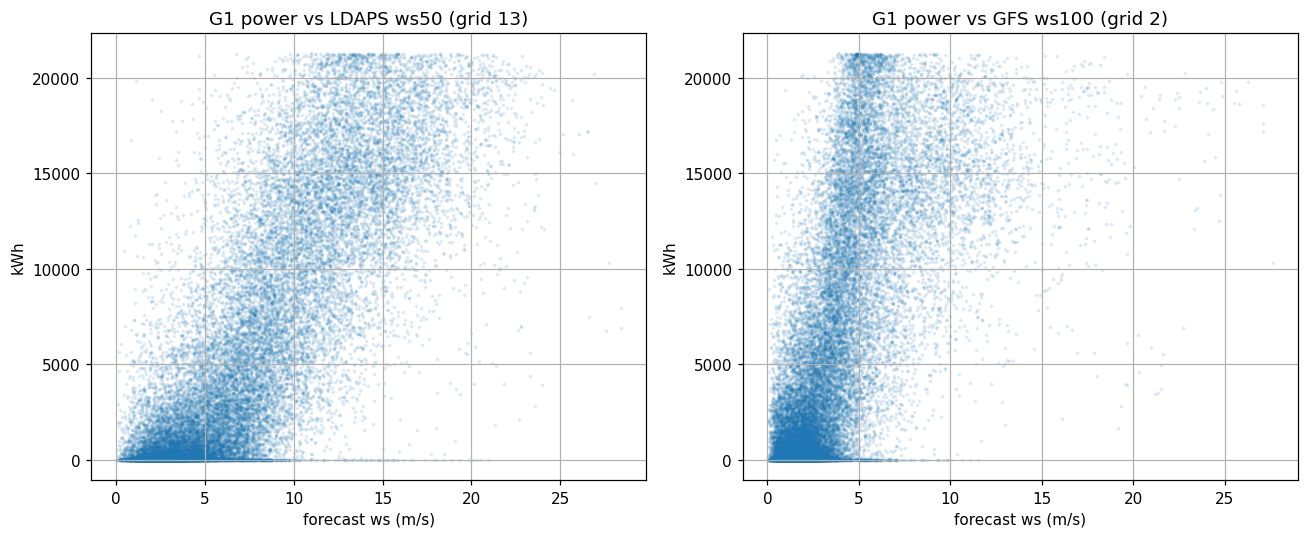

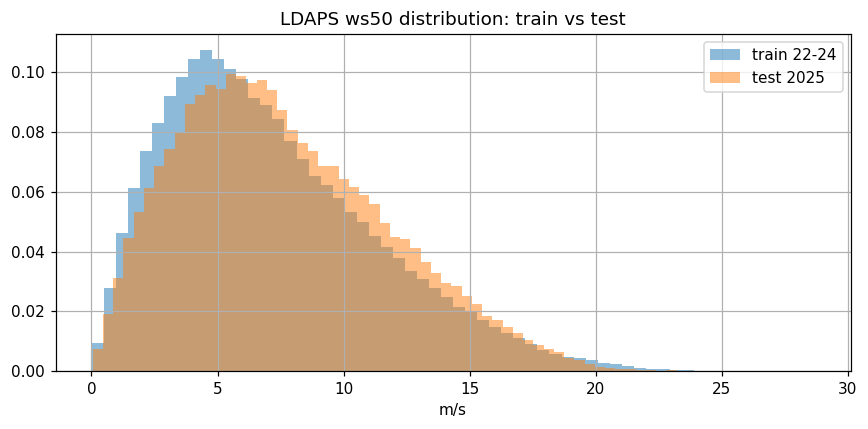


[5] METRIC FUNCTIONS + NAIVE BASELINE SIMULATION

Validation on 2024 (train stats from 2022-2023), n=8,784
baseline                 NMAE   1-NMAE     FICR
always_capacity        0.5016   0.4984   0.0596
always_zero            0.4984   0.5016   0.0000
global_mean            0.2658   0.7342   0.1708
month_hour_mean        0.2516   0.7484   0.1954

  * 이 표가 '모델 없이 도달 가능한 하한선'. NWP 피처를 쓰는 순간 이걸 크게 넘어야 정상.
  * FICR은 오차 6%/8% 구간에 민감 → NMAE가 같아도 FICR은 다를 수 있음에 주목.

EDA COMPLETE. Saved figures: fig_2_1 ~ fig_4_6 (.png)


In [5]:
# ============================================================
# BARAM 2026 풍력발전량 예측 대회 — EDA 스크립트 (Colab용)
# ============================================================
# 사용법 (Colab):
#   1) 데이터 파일들을 Colab 작업 디렉토리(또는 Drive)에 업로드
#   2) DATA_DIR 경로를 수정
#   3) 셀 단위로 나눠 실행하거나 전체 실행
#
# 섹션 구성:
#   [0] 설정 & 로드
#   [1] 기본 무결성 점검 (기간/결측/중복/연속성)
#   [2] 라벨(발전량) EDA — 분포, 계절성, 10% 제외 규칙 영향
#   [3] SCADA EDA — 파워 커브, 이상치(정지/출력제한), 라벨 정합성
#   [4] NWP EDA — U/V 변환, 격자별 상관, LDAPS vs GFS, 풍속 편향
#   [5] 나이브 베이스라인 채점 시뮬레이션 (NMAE / FICR)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 플롯 라벨은 영어 사용 (Colab 한글 폰트 깨짐 방지)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

# ------------------------------------------------------------
# [0] 설정 & 로드
# ------------------------------------------------------------
DATA_DIR = "./"   # <-- Colab 경로에 맞게 수정 (예: /content/drive/MyDrive/baram2026/)

ENC = "utf-8-sig"
CAPACITY_KWH = {"kpx_group_1": 21600.0, "kpx_group_2": 21600.0, "kpx_group_3": 21000.0}
GROUPS = list(CAPACITY_KWH.keys())

# 터빈-그룹 매핑 (info.xlsx 기준)
G1_TURBINES = [f"vestas_wtg{i:02d}" for i in range(1, 7)]    # VESTAS 1-6호기
G2_TURBINES = [f"vestas_wtg{i:02d}" for i in range(7, 13)]   # VESTAS 7-12호기
G3_TURBINES = [f"unison_wtg{i:02d}" for i in range(1, 6)]    # UNISON 1-5호기

print("Loading data ...")
labels = pd.read_csv(DATA_DIR + "train_labels.csv", encoding=ENC, parse_dates=["kst_dtm"])
scada_v = pd.read_csv(DATA_DIR + "scada_vestas_train.csv", encoding=ENC, parse_dates=["kst_dtm"])
scada_u = pd.read_csv(DATA_DIR + "scada_unison_train.csv", encoding=ENC, parse_dates=["kst_dtm"])
ldaps_tr = pd.read_csv(DATA_DIR + "ldaps_train.csv", encoding=ENC,
                       parse_dates=["forecast_kst_dtm", "data_available_kst_dtm"])
gfs_tr = pd.read_csv(DATA_DIR + "gfs_train.csv", encoding=ENC,
                     parse_dates=["forecast_kst_dtm", "data_available_kst_dtm"])
ldaps_te = pd.read_csv(DATA_DIR + "ldaps_test.csv", encoding=ENC,
                       parse_dates=["forecast_kst_dtm", "data_available_kst_dtm"])
gfs_te = pd.read_csv(DATA_DIR + "gfs_test.csv", encoding=ENC,
                     parse_dates=["forecast_kst_dtm", "data_available_kst_dtm"])
print("done.")

# ------------------------------------------------------------
# [1] 기본 무결성 점검
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("[1] BASIC INTEGRITY CHECKS")
print("=" * 60)

def check_hourly_continuity(dt_series, name):
    """1시간 간격 연속성 확인"""
    s = pd.Series(sorted(dt_series.unique()))
    full = pd.date_range(s.min(), s.max(), freq="h")
    missing = set(full) - set(s)
    dup = dt_series.duplicated().sum()
    print(f"  {name}: {s.min()} ~ {s.max()} | rows(unique dt)={len(s)} "
          f"| missing hours={len(missing)} | dup={dup}")
    if 0 < len(missing) <= 10:
        print(f"    -> missing: {sorted(missing)}")
    return missing

print("\n-- Time continuity --")
check_hourly_continuity(labels["kst_dtm"], "labels")
check_hourly_continuity(ldaps_tr["forecast_kst_dtm"], "ldaps_train")
check_hourly_continuity(gfs_tr["forecast_kst_dtm"], "gfs_train")
check_hourly_continuity(ldaps_te["forecast_kst_dtm"], "ldaps_test")
check_hourly_continuity(gfs_te["forecast_kst_dtm"], "gfs_test")

print("\n-- Grid count per timestamp (should be constant: LDAPS=16, GFS=9) --")
for df, name, expect in [(ldaps_tr, "ldaps_train", 16), (gfs_tr, "gfs_train", 9)]:
    cnt = df.groupby("forecast_kst_dtm")["grid_id"].count()
    print(f"  {name}: min={cnt.min()}, max={cnt.max()} (expect {expect})")

print("\n-- Missing values (labels) --")
print(labels.isna().sum().to_string())
print("  * group_3 은 2022년 구간이 결측으로 제공됨 (명세서와 일치 여부 확인)")
g3_na_period = labels.loc[labels["kpx_group_3"].isna(), "kst_dtm"]
if len(g3_na_period):
    print(f"    group_3 NaN range: {g3_na_period.min()} ~ {g3_na_period.max()}")

print("\n-- Missing values (NWP, top 10) --")
print("LDAPS train:\n", ldaps_tr.isna().sum().sort_values(ascending=False).head(10).to_string())
print("GFS train:\n", gfs_tr.isna().sum().sort_values(ascending=False).head(10).to_string())

print("\n-- SCADA missing ratio per turbine (power) --")
for df, cols in [(scada_v, G1_TURBINES + G2_TURBINES), (scada_u, G3_TURBINES)]:
    for t in cols:
        c = f"{t}_power_kw10m"
        if c in df.columns:
            na = df[c].isna().mean() * 100
            neg = (df[c] < 0).mean() * 100
            print(f"  {t}: NaN {na:5.2f}% | negative {neg:5.2f}%")

# 라벨 음수/용량 초과 체크
print("\n-- Label range sanity --")
for g in GROUPS:
    v = labels[g].dropna()
    over = (v > CAPACITY_KWH[g]).sum()
    neg = (v < 0).sum()
    print(f"  {g}: min={v.min():.1f}, max={v.max():.1f}, "
          f"capacity={CAPACITY_KWH[g]:.0f}, over-capacity rows={over}, negative rows={neg}")

# ------------------------------------------------------------
# [2] 라벨(발전량) EDA
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("[2] LABEL (POWER OUTPUT) EDA")
print("=" * 60)

lab = labels.copy()
lab["year"] = lab["kst_dtm"].dt.year
lab["month"] = lab["kst_dtm"].dt.month
lab["hour"] = lab["kst_dtm"].dt.hour

# (2-1) 히스토그램 + 10% 제외선
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, g in zip(axes, GROUPS):
    v = lab[g].dropna()
    thr = CAPACITY_KWH[g] * 0.10
    ax.hist(v, bins=80, alpha=0.8)
    ax.axvline(thr, color="red", ls="--", label=f"10% cap = {thr:.0f}")
    ax.set_title(f"{g} distribution")
    ax.set_xlabel("kWh"); ax.legend()
plt.tight_layout(); plt.savefig("fig_2_1_label_hist.png"); plt.show()

# (2-2) 10% 제외 규칙 영향 — 평가에 실제로 들어가는 샘플 비율
print("\n-- 10% exclusion rule impact (train period) --")
for g in GROUPS:
    v = lab[g].dropna()
    thr = CAPACITY_KWH[g] * 0.10
    excl = (v < thr).mean() * 100
    print(f"  {g}: {excl:5.1f}% of hours EXCLUDED from scoring "
          f"(actual < {thr:.0f} kWh) -> only {100-excl:.1f}% evaluated")

# 월별 제외 비율 (계절성)
fig, ax = plt.subplots(figsize=(10, 4))
for g in GROUPS:
    thr = CAPACITY_KWH[g] * 0.10
    m = lab.dropna(subset=[g]).groupby("month")[g].apply(lambda s: (s < thr).mean() * 100)
    ax.plot(m.index, m.values, marker="o", label=g)
ax.set_title("Monthly ratio of EXCLUDED hours (actual < 10% capacity)")
ax.set_xlabel("month"); ax.set_ylabel("% excluded"); ax.legend()
plt.tight_layout(); plt.savefig("fig_2_2_excluded_by_month.png"); plt.show()

# (2-3) 계절성: 월별/시간대별 평균 이용률(capacity factor)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for g in GROUPS:
    cf_m = lab.groupby("month")[g].mean() / CAPACITY_KWH[g] * 100
    axes[0].plot(cf_m.index, cf_m.values, marker="o", label=g)
    cf_h = lab.groupby("hour")[g].mean() / CAPACITY_KWH[g] * 100
    axes[1].plot(cf_h.index, cf_h.values, marker="o", label=g)
axes[0].set_title("Capacity factor by MONTH (%)"); axes[0].set_xlabel("month")
axes[1].set_title("Capacity factor by HOUR (%)"); axes[1].set_xlabel("hour of day")
for a in axes: a.legend(); a.set_ylabel("%")
plt.tight_layout(); plt.savefig("fig_2_3_seasonality.png"); plt.show()

# (2-4) 연도별 분포 안정성 (2025 테스트 일반화 가늠)
print("\n-- Yearly mean capacity factor (%) --")
print((lab.groupby("year")[GROUPS].mean() / pd.Series(CAPACITY_KWH) * 100).round(1).to_string())

# (2-5) 그룹 간 상관
print("\n-- Inter-group correlation --")
print(lab[GROUPS].corr().round(3).to_string())

# ------------------------------------------------------------
# [3] SCADA EDA — 파워 커브 & 이상치 & 라벨 정합성
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("[3] SCADA EDA")
print("=" * 60)

# ★ 사전 검증으로 확인된 사실 (중요):
#   - power_kw10m 은 "10분 평균 kW"가 아니라 "10분 구간 에너지(kWh)"임.
#     -> 시간당 kWh = 6개 구간의 합 (sum), sum/6 이 아님!
#     -> 검증: 그룹별 시간 집계 sum vs 라벨 corr = 0.9998(G1/G2), 0.9966(G3), 스케일비 ≈ 1.0
#   - VESTAS 컬럼에는 두 종류의 비정상값 존재:
#     (a) 소량 음수(-1 ~ -5 수준, 약 15.7%): 터빈 대기전력 소비로 추정 (정상 신호)
#     (b) |값| 4천만대 극단치: 센서/카운터 글리치 (제거 필수)
#   - 10분 kWh 물리적 상한: VESTAS 3.6MW -> 600 kWh, UNISON 4.2MW -> 700 kWh

VESTAS_MAX_KWH10M = 3600 / 6   # 600
UNISON_MAX_KWH10M = 4200 / 6   # 700
GLITCH_TOL = 1.30              # 물리 상한의 130%까지는 순간 과출력으로 허용

def clean_power(s: pd.Series, max_kwh: float) -> pd.Series:
    """글리치 제거: 물리 상한×허용치 초과 또는 큰 음수 -> NaN. 소량 음수는 유지."""
    out = s.copy()
    out[(out > max_kwh * GLITCH_TOL) | (out < -max_kwh)] = np.nan
    return out

for t in G1_TURBINES + G2_TURBINES:
    c = f"{t}_power_kw10m"
    scada_v[c] = clean_power(scada_v[c], VESTAS_MAX_KWH10M)
for t in G3_TURBINES:
    c = f"{t}_power_kw10m"
    scada_u[c] = clean_power(scada_u[c], UNISON_MAX_KWH10M)

print("\n-- Glitch removal summary --")
print(f"  VESTAS: values outside [-600, {VESTAS_MAX_KWH10M*GLITCH_TOL:.0f}] kWh/10m -> NaN")
print(f"  UNISON: values outside [-700, {UNISON_MAX_KWH10M*GLITCH_TOL:.0f}] kWh/10m -> NaN")

# (3-1) 터빈별 파워 커브 (평균 kW로 환산해 표시: kWh/10m × 6)
def plot_power_curves(df, turbines, title, fname, ncol=6):
    n = len(turbines)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.8 * nrow), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    for i, t in enumerate(turbines):
        ax = axes[i // ncol, i % ncol]
        ws, pw = f"{t}_ws", f"{t}_power_kw10m"
        if ws in df.columns and pw in df.columns:
            d = df[[ws, pw]].dropna()
            d = d.sample(min(len(d), 15000), random_state=0)  # 렌더링 속도
            ax.scatter(d[ws], d[pw] * 6, s=1, alpha=0.15)     # kWh/10m -> 평균 kW
        ax.set_title(t, fontsize=9)
    fig.suptitle(title)
    fig.supxlabel("wind speed (m/s)"); fig.supylabel("avg power (kW)")
    plt.tight_layout(); plt.savefig(fname); plt.show()

plot_power_curves(scada_v, G1_TURBINES + G2_TURBINES,
                  "Power curves — VESTAS V126 (wtg01-06: G1, wtg07-12: G2)",
                  "fig_3_1_pc_vestas.png")
plot_power_curves(scada_u, G3_TURBINES,
                  "Power curves — UNISON U136 (G3)", "fig_3_1_pc_unison.png", ncol=5)

# (3-2) 이상치 정량화: "바람은 부는데(>= cut-in+2) 출력 0" 비율 = 정지/정비 추정
print("\n-- Anomaly: zero power despite wind >= 5 m/s (downtime proxy, % of rows) --")
for df, cols in [(scada_v, G1_TURBINES + G2_TURBINES), (scada_u, G3_TURBINES)]:
    for t in cols:
        ws, pw = f"{t}_ws", f"{t}_power_kw10m"
        if ws in df.columns:
            d = df[[ws, pw]].dropna()
            bad = ((d[ws] >= 5) & (d[pw] <= 0)).mean() * 100
            print(f"  {t}: {bad:5.2f}%")

# (3-3) SCADA(10분 kWh) -> 시간 kWh 집계가 라벨과 맞는지 정합성 확인
#   ★ 시간당 에너지(kWh) = 6개 10분 구간 에너지의 "합" (sum). sum/6 아님!
def scada_hourly_group_energy(df, turbines):
    pw_cols = [f"{t}_power_kw10m" for t in turbines if f"{t}_power_kw10m" in df.columns]
    d = df[["kst_dtm"] + pw_cols].copy()
    d["grp_kwh10m"] = d[pw_cols].sum(axis=1)
    # 집계 구간 종료 시각 라벨과 맞추기 위해: (t-1h, t] 구간 → ceil
    d["hour_end"] = d["kst_dtm"].dt.ceil("h")
    agg = d.groupby("hour_end").agg(kwh=("grp_kwh10m", "sum"),
                                    n=("grp_kwh10m", "size"))
    return agg

print("\n-- SCADA hourly aggregate vs labels (correlation & MAE) --")
for gname, sdf, tlist in [("kpx_group_1", scada_v, G1_TURBINES),
                          ("kpx_group_2", scada_v, G2_TURBINES),
                          ("kpx_group_3", scada_u, G3_TURBINES)]:
    agg = scada_hourly_group_energy(sdf, tlist)
    m = labels.set_index("kst_dtm")[[gname]].join(agg, how="inner").dropna()
    m = m[m["n"] == 6]  # 완전한 시간만
    corr = m[gname].corr(m["kwh"])
    mae = (m[gname] - m["kwh"]).abs().mean()
    print(f"  {gname}: corr={corr:.4f}, MAE={mae:,.0f} kWh, n={len(m):,}")
print("  * corr≈1 이면 라벨 = SCADA 합산과 동일 구조 → SCADA로 라벨 품질/정지 보정 판단 가능")

# ------------------------------------------------------------
# [4] NWP EDA — U/V 변환, 격자 상관, 편향
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("[4] NWP (LDAPS / GFS) EDA")
print("=" * 60)

def uv_to_ws(u, v):
    return np.sqrt(u ** 2 + v ** 2)

def uv_to_wd(u, v):
    """기상학 관례: 바람이 불어오는 방향 (0=N, 90=E)"""
    return (np.degrees(np.arctan2(-u, -v))) % 360

# (4-1) 대표 풍속 피처 생성
#   LDAPS: 10m 풍속 + 50m(max/min 평균) 풍속
ld = ldaps_tr.copy()
ld["ws10"] = uv_to_ws(ld["heightAboveGround_10_10u"], ld["heightAboveGround_10_10v"])
ld["u50"] = (ld["heightAboveGround_50_50MUmax"] + ld["heightAboveGround_50_50MUmin"]) / 2
ld["v50"] = (ld["heightAboveGround_50_50MVmax"] + ld["heightAboveGround_50_50MVmin"]) / 2
ld["ws50"] = uv_to_ws(ld["u50"], ld["v50"])

#   GFS: 10m/80m/100m 풍속 (100m가 허브높이 117m에 가장 가까움)
gf = gfs_tr.copy()
gf["ws10"] = uv_to_ws(gf["heightAboveGround_10_10u"], gf["heightAboveGround_10_10v"])
gf["ws80"] = uv_to_ws(gf["heightAboveGround_80_u"], gf["heightAboveGround_80_v"])
gf["ws100"] = uv_to_ws(gf["heightAboveGround_100_100u"], gf["heightAboveGround_100_100v"])

lab_idx = labels.set_index("kst_dtm")

# (4-2) 격자별 풍속-발전량 상관 → 중요한 격자 찾기
print("\n-- Grid-wise correlation: LDAPS ws50 vs group power --")
ld_piv = ld.pivot_table(index="forecast_kst_dtm", columns="grid_id", values="ws50")
res = {}
for g in GROUPS:
    joined = ld_piv.join(lab_idx[g], how="inner").dropna()
    res[g] = joined.iloc[:, :-1].corrwith(joined[g])
ld_corr = pd.DataFrame(res).round(3)
print(ld_corr.to_string())
print(f"  -> best LDAPS grid per group: {ld_corr.idxmax().to_dict()}")

print("\n-- Grid-wise correlation: GFS ws100 vs group power --")
gf_piv = gf.pivot_table(index="forecast_kst_dtm", columns="grid_id", values="ws100")
res = {}
for g in GROUPS:
    joined = gf_piv.join(lab_idx[g], how="inner").dropna()
    res[g] = joined.iloc[:, :-1].corrwith(joined[g])
gf_corr = pd.DataFrame(res).round(3)
print(gf_corr.to_string())
print(f"  -> best GFS grid per group: {gf_corr.idxmax().to_dict()}")

# (4-3) 높이별 풍속 비교 (GFS): 10m vs 80m vs 100m 상관
print("\n-- GFS wind height comparison (grid-mean ws vs kpx_group_1) --")
gf_mean = gf.groupby("forecast_kst_dtm")[["ws10", "ws80", "ws100"]].mean()
joined = gf_mean.join(lab_idx["kpx_group_1"], how="inner").dropna()
print(joined.corr()["kpx_group_1"].round(3).to_string())

# (4-4) NWP 풍속 vs SCADA 관측 풍속 — 체계적 편향(bias) 확인
#   SCADA 풍속(그룹1 터빈 평균, 시간 평균) vs LDAPS/GFS 대표 풍속
ws_cols_g1 = [f"{t}_ws" for t in G1_TURBINES]
sc = scada_v[["kst_dtm"] + ws_cols_g1].copy()
sc["obs_ws"] = sc[ws_cols_g1].mean(axis=1)
sc["hour_end"] = sc["kst_dtm"].dt.ceil("h")
obs_h = sc.groupby("hour_end")["obs_ws"].mean()

ld_best_grid = ld_corr["kpx_group_1"].idxmax()
gf_best_grid = gf_corr["kpx_group_1"].idxmax()
cmp = pd.DataFrame({
    "obs": obs_h,
    "ldaps_ws50": ld_piv[ld_best_grid],
    "gfs_ws100": gf_piv[gf_best_grid],
}).dropna()

print("\n-- NWP vs SCADA-observed wind speed (Group1 turbines avg) --")
for c in ["ldaps_ws50", "gfs_ws100"]:
    bias = (cmp[c] - cmp["obs"]).mean()
    rmse = np.sqrt(((cmp[c] - cmp["obs"]) ** 2).mean())
    corr = cmp[c].corr(cmp["obs"])
    print(f"  {c} (best grid): bias={bias:+.2f} m/s, RMSE={rmse:.2f}, corr={corr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, c in zip(axes, ["ldaps_ws50", "gfs_ws100"]):
    d = cmp.sample(min(len(cmp), 20000), random_state=0)
    ax.scatter(d["obs"], d[c], s=2, alpha=0.15)
    lim = [0, max(d["obs"].max(), d[c].max())]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel("SCADA observed ws (m/s)"); ax.set_ylabel(f"{c} (m/s)")
    ax.set_title(f"{c} vs observed")
plt.tight_layout(); plt.savefig("fig_4_4_nwp_bias.png"); plt.show()

# (4-5) 발전량 vs NWP 풍속 — "예보 기반 파워 커브" (모델이 배울 관계 그 자체)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
j1 = ld_piv[[ld_best_grid]].join(lab_idx["kpx_group_1"]).dropna()
axes[0].scatter(j1[ld_best_grid], j1["kpx_group_1"], s=2, alpha=0.1)
axes[0].set_title(f"G1 power vs LDAPS ws50 (grid {ld_best_grid})")
j2 = gf_piv[[gf_best_grid]].join(lab_idx["kpx_group_1"]).dropna()
axes[1].scatter(j2[gf_best_grid], j2["kpx_group_1"], s=2, alpha=0.1)
axes[1].set_title(f"G1 power vs GFS ws100 (grid {gf_best_grid})")
for a in axes: a.set_xlabel("forecast ws (m/s)"); a.set_ylabel("kWh")
plt.tight_layout(); plt.savefig("fig_4_5_forecast_powercurve.png"); plt.show()

# (4-6) train/test 분포 비교 (covariate shift 점검)
ld_te = ldaps_te.copy()
ld_te["u50"] = (ld_te["heightAboveGround_50_50MUmax"] + ld_te["heightAboveGround_50_50MUmin"]) / 2
ld_te["v50"] = (ld_te["heightAboveGround_50_50MVmax"] + ld_te["heightAboveGround_50_50MVmin"]) / 2
ld_te["ws50"] = uv_to_ws(ld_te["u50"], ld_te["v50"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ld["ws50"], bins=60, alpha=0.5, density=True, label="train 22-24")
ax.hist(ld_te["ws50"], bins=60, alpha=0.5, density=True, label="test 2025")
ax.set_title("LDAPS ws50 distribution: train vs test"); ax.set_xlabel("m/s"); ax.legend()
plt.tight_layout(); plt.savefig("fig_4_6_train_test_shift.png"); plt.show()

# ------------------------------------------------------------
# [5] 평가지표 함수 + 나이브 베이스라인 시뮬레이션
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("[5] METRIC FUNCTIONS + NAIVE BASELINE SIMULATION")
print("=" * 60)

def nmae_score(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
    """10% 제외 규칙 적용 NMAE (그룹 평균). y_true/y_pred: GROUPS 컬럼 보유."""
    per_g = []
    for g in GROUPS:
        cap = CAPACITY_KWH[g]
        m = y_true[g].notna() & (y_true[g] >= 0.10 * cap)   # 제외 규칙
        if m.sum() == 0:
            continue
        per_g.append((np.abs(y_pred.loc[m, g] - y_true.loc[m, g]) / cap).mean())
    return float(np.mean(per_g))

def ficr_score(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
    """정산금 획득률: 오차율<=6% → 4원, <=8% → 3원, 초과 → 0원. 이론최대=4원."""
    per_g = []
    for g in GROUPS:
        cap = CAPACITY_KWH[g]
        m = y_true[g].notna() & (y_true[g] >= 0.10 * cap)
        if m.sum() == 0:
            continue
        err = np.abs(y_pred.loc[m, g] - y_true.loc[m, g]) / cap
        won = np.where(err <= 0.06, 4.0, np.where(err <= 0.08, 3.0, 0.0))
        per_g.append(won.sum() / (4.0 * m.sum()))
    return float(np.mean(per_g))

# 나이브 베이스라인 4종을 2024년(홀드아웃)에 채점
train_part = lab[lab["year"] <= 2023].copy()
valid_part = lab[lab["year"] == 2024].reset_index(drop=True)

baselines = {}
# (a) 항상 설비용량 (제공된 baseline_submit 스타일)
baselines["always_capacity"] = pd.DataFrame(
    {g: np.full(len(valid_part), CAPACITY_KWH[g]) for g in GROUPS})
# (b) 항상 0
baselines["always_zero"] = pd.DataFrame({g: np.zeros(len(valid_part)) for g in GROUPS})
# (c) 학습기간 전체 평균
baselines["global_mean"] = pd.DataFrame(
    {g: np.full(len(valid_part), train_part[g].mean()) for g in GROUPS})
# (d) 월×시간대 평균 (계절성 기반, NWP 없이 낼 수 있는 최선의 무모델)
mh_mean = train_part.groupby(["month", "hour"])[GROUPS].mean()
key = valid_part.set_index(["month", "hour"]).index
baselines["month_hour_mean"] = mh_mean.reindex(key).reset_index(drop=True)[GROUPS] \
    .fillna(train_part[GROUPS].mean())

print(f"\nValidation on 2024 (train stats from 2022-2023), n={len(valid_part):,}")
print(f"{'baseline':<20} {'NMAE':>8} {'1-NMAE':>8} {'FICR':>8}")
for name, pred in baselines.items():
    nm = nmae_score(valid_part, pred)
    fi = ficr_score(valid_part, pred)
    print(f"{name:<20} {nm:8.4f} {1-nm:8.4f} {fi:8.4f}")
print("\n  * 이 표가 '모델 없이 도달 가능한 하한선'. NWP 피처를 쓰는 순간 이걸 크게 넘어야 정상.")
print("  * FICR은 오차 6%/8% 구간에 민감 → NMAE가 같아도 FICR은 다를 수 있음에 주목.")

print("\nEDA COMPLETE. Saved figures: fig_2_1 ~ fig_4_6 (.png)")